In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


In [2]:
# Standard library imports
import sys
from pathlib import Path

# Third-party scientific computing
import numpy as np
import pandas as pd

# Deep learning frameworks
import torch
import pytorch_lightning as pl

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.pipeline import Pipeline

# Local imports - data processing
from src.data_models.caravanify import Caravanify, CaravanifyConfig
from src.data_models.datamodule import HydroDataModule
from src.preprocessing.grouped import GroupedTransformer
from src.preprocessing.standard_scale import StandardScaleTransformer

# Local imports - models and evaluation
from src.models.TSMixer import LitTSMixer, TSMixerConfig
from src.models.evaluators import TSForecastEvaluator

# Append parent directory to path (if needed)
sys.path.append(str(Path().absolute().parent))

---

# Load the trained model

In [3]:
# Benchmark model configuration
BENCHMARK_INPUT_LENGTH: int = 256
BENCHMARK_OUTPUT_LENGTH: int = 10
BENCHMARK_HIDDEN_SIZE: int = 64
BENCHMARK_DROPOUT: float = 0.4
BENCHMARK_NUM_LAYERS: int = 2
BENCHMARK_STATIC_EMBEDDING_SIZE: int = 20
BENCHMARK_LEARNING_RATE: float = 0.00085

# Challenger model configuration
CHALLENGER_INPUT_LENGTH: int = 256
CHALLENGER_OUTPUT_LENGTH: int = 10
CHALLENGER_HIDDEN_SIZE: int = 128
CHALLENGER_DROPOUT: float = 0.3
CHALLENGER_NUM_LAYERS: int = 13
CHALLENGER_STATIC_EMBEDDING_SIZE: int = 9
CHALLENGER_LEARNING_RATE: float = 2e-5


STATIC_FEATURES = [
    "gauge_id",
    "p_mean",
    "area",
    "ele_mt_sav",
    "high_prec_dur",
    "frac_snow",
    "high_prec_freq",
    "slp_dg_sav",
    "cly_pc_sav",
    "aridity_ERA5_LAND",
    "aridity_FAO_PM",
]

FORCING_FEATURES = [
    "snow_depth_water_equivalent_mean",
    "surface_net_solar_radiation_mean",
    "surface_net_thermal_radiation_mean",
    "potential_evaporation_sum_ERA5_LAND",
    "potential_evaporation_sum_FAO_PENMAN_MONTEITH",
    "temperature_2m_mean",
    "temperature_2m_min",
    "temperature_2m_max",
    "total_precipitation_sum",
]

TARGET = "streamflow"

benchmark_config = TSMixerConfig(
    input_len=BENCHMARK_INPUT_LENGTH,
    input_size=len(FORCING_FEATURES) + 1,  # +1 for target
    output_len=BENCHMARK_OUTPUT_LENGTH,
    static_size=len(STATIC_FEATURES) - 1,  # -1 for gauge_id
    hidden_size=BENCHMARK_HIDDEN_SIZE,
    static_embedding_size=BENCHMARK_STATIC_EMBEDDING_SIZE,
    num_layers=BENCHMARK_NUM_LAYERS,
    dropout=BENCHMARK_DROPOUT,
    learning_rate=BENCHMARK_LEARNING_RATE,
    group_identifier="gauge_id",
    lr_scheduler_patience=5,
    lr_scheduler_factor=0.5,
)

challenger_config = TSMixerConfig(
    input_len=CHALLENGER_INPUT_LENGTH,
    input_size=len(FORCING_FEATURES) + 1,  # +1 for target
    output_len=CHALLENGER_OUTPUT_LENGTH,
    static_size=len(STATIC_FEATURES) - 1,  # -1 for gauge_id
    hidden_size=CHALLENGER_HIDDEN_SIZE,
    static_embedding_size=CHALLENGER_STATIC_EMBEDDING_SIZE,
    num_layers=CHALLENGER_NUM_LAYERS,
    dropout=CHALLENGER_DROPOUT,
    learning_rate=CHALLENGER_LEARNING_RATE,
    group_identifier="gauge_id",
    lr_scheduler_patience=5,
    lr_scheduler_factor=0.5,
)

In [4]:
print("CONFIGURING CA DATASET (BASELINE)")
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
    # human_influence_path="/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv",
    gauge_id_prefix="CA",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)

ca_caravan = Caravanify(config)
ca_basins = ca_caravan.get_all_gauge_ids()

print(f"Found {len(ca_basins)} total CA basins")

ca_caravan.load_stations(ca_basins)

# Prepare data frames
ts_columns = FORCING_FEATURES + [TARGET]
static_columns = STATIC_FEATURES

ca_ts_data = ca_caravan.get_time_series()[
    ts_columns + ["date"] + ["gauge_id"]
]
ca_static_data = ca_caravan.get_static_attributes()[static_columns]

CONFIGURING CA DATASET (BASELINE)
Found 78 total CA basins


In [5]:
feature_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

target_pipeline = GroupedTransformer(
    Pipeline([("scaler", StandardScaleTransformer())]),
    columns=[TARGET],
    group_identifier="gauge_id",
    n_jobs=-1,
)

static_pipeline = Pipeline([("scaler", StandardScaleTransformer())])

preprocessing_config = {
    "features": {"pipeline": feature_pipeline},
    "target": {"pipeline": target_pipeline},
    "static_features": {"pipeline": static_pipeline},
}

In [6]:
STATIC_FEATURES = [col for col in static_columns if col != "gauge_id"]
FORCING_FEATURES = FORCING_FEATURES + [TARGET]

data_module = HydroDataModule(
    time_series_df=ca_ts_data,
    static_df=ca_static_data,
    group_identifier="gauge_id",
    preprocessing_config=preprocessing_config,
    batch_size=2048,
    input_length=BENCHMARK_INPUT_LENGTH,
    output_length=BENCHMARK_OUTPUT_LENGTH,
    num_workers=4,
    features=FORCING_FEATURES,
    static_features=STATIC_FEATURES,
    target=TARGET,
    min_train_years=8,
    val_years=2,
    test_years=3,
    max_missing_pct=10,
    domain_id="CA",
)

data_module.prepare_data()
data_module.setup()

Original basins: 78
Retained basins: 44
Domain CA (source): Created 254171 valid sequences from 44 catchments
Domain CA (source): Created 19896 valid sequences from 44 catchments
Domain CA (source): Created 34062 valid sequences from 44 catchments


In [8]:
benchmark_path = "/Users/cooper/Desktop/CAMELS-CH/experiments/Merged/saved_models/merged_dataset_benchmark/tsmixer_benchmark_0.ckpt"
challenger_path = "/Users/cooper/Desktop/CAMELS-CH/experiments/Merged/saved_models/merged_dataset_challenger/tsmixer_challenger_0.ckpt"

benchmark = LitTSMixer.load_from_checkpoint(benchmark_path, config=benchmark_config)
challenger = LitTSMixer.load_from_checkpoint(challenger_path, config=challenger_config)

In [9]:
evaluator = TSForecastEvaluator(
    datamodule=data_module,
    horizons=list(range(1, 11)),
    models={
        "challenger": challenger,
        "benchmark": benchmark,
    },
    benchmark_model="benchmark",
    trainer_kwargs={"accelerator": "cpu", "devices": 1},
)

In [10]:
# Run evaluation
results = evaluator.test_models()

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Testing challenger...


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 78
Retained basins: 44
Domain CA (source): Created 34062 valid sequences from 44 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

...

Testing benchmark...


/Users/cooper/Desktop/CAMELS-CH/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


Original basins: 78
Retained basins: 44
Domain CA (source): Created 34062 valid sequences from 44 catchments


Testing: |          | 0/? [00:00<?, ?it/s]

Predictions shape: torch.Size([34062, 10])
Observations shape: torch.Size([34062, 10])
Number of basin_ids: 34062
Number of input_end_dates: 34062
Configured horizons: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Evaluating results with shape: preds=(34062, 10), obs=(34062, 10), basin_ids=(34062,)


In [11]:
evaluator.summarize_metrics(results["challenger"]["basin_metrics"], per_basin=True)

MSE       MAE       NSE      RMSE
basin_id horizon                                        
CA_15013 1        0.232354  0.299037  0.912319  0.482031
         2        0.325546  0.330678  0.877255  0.570567
         3        0.418307  0.359805  0.842414  0.646767
         4        0.483343  0.386030  0.818068  0.695229
         5        0.548288  0.414826  0.793804  0.740465
...                    ...       ...       ...       ...
CA_17462 6        0.016764  0.072620  0.397318  0.129476
         7        0.018711  0.077409  0.328259  0.136789
         8        0.020379  0.081641  0.269406  0.142755
         9        0.022332  0.087220  0.200578  0.149440
         10       0.023454  0.091264  0.161695  0.153145

[440 rows x 4 columns]

In [12]:
evaluator.summarize_metrics(results["benchmark"]["basin_metrics"], per_basin=True)

MSE       MAE       NSE      RMSE
basin_id horizon                                        
CA_15013 1        0.133355  0.210422  0.949677  0.365178
         2        0.223758  0.257129  0.915634  0.473030
         3        0.314355  0.304712  0.881575  0.560673
         4        0.397077  0.335795  0.850539  0.630141
         5        0.476181  0.368262  0.820921  0.690058
...                    ...       ...       ...       ...
CA_17462 6        0.016408  0.059531  0.410101  0.128095
         7        0.018186  0.065674  0.347110  0.134856
         8        0.020157  0.070616  0.277372  0.141974
         9        0.021516  0.074769  0.229814  0.146682
         10       0.022755  0.077780  0.186667  0.150847

[440 rows x 4 columns]

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '10-day Forecast for CA_15022'}, xlabel='Date', ylabel='Streamflow'>)

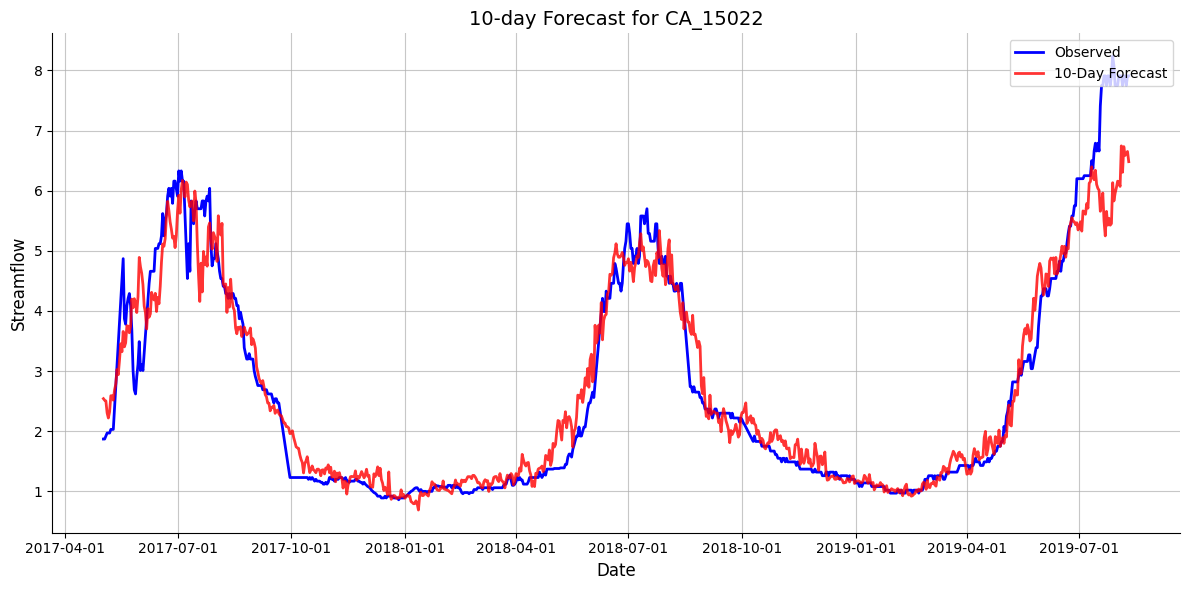

In [13]:
evaluator.plot_rolling_forecast(
    df=results["challenger"]["df"], 
    horizon=10, 
    group_identifier="CA_15022"
)

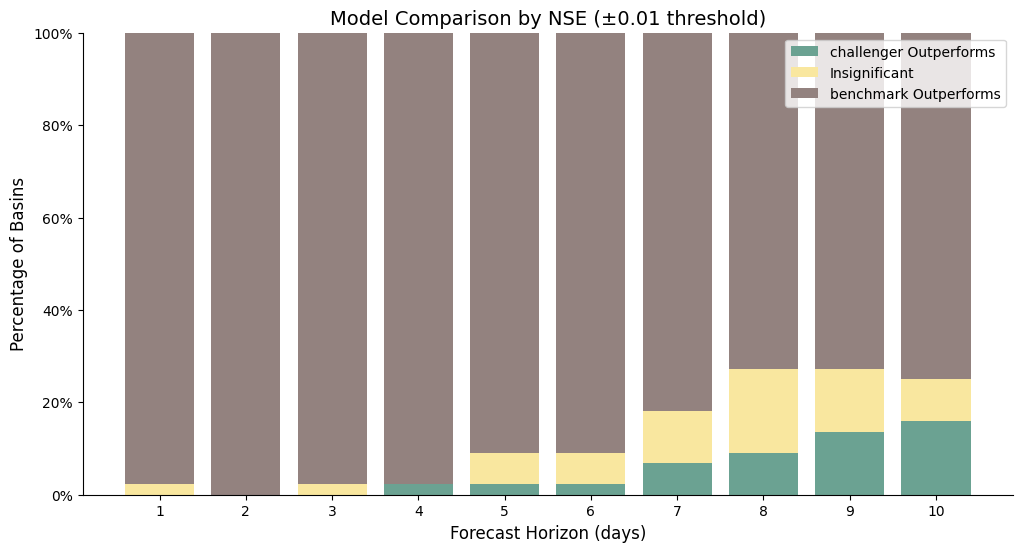

{'avg_better': np.float64(5.2272727272727275), 'avg_insignificant': np.float64(7.045454545454545), 'avg_worse': np.float64(87.72727272727273), 'best_horizon': np.int64(10), 'best_horizon_pct': np.float64(15.909090909090908), 'worst_horizon': np.int64(1), 'worst_horizon_pct': np.float64(0.0)}


In [14]:
comparison_results = evaluator.compare_models("benchmark", "challenger", metric="NSE", threshold=0.01)

# Plot the stacked bar chart of the comparison results
fig, ax = evaluator.plot_model_comparison(comparison_results)
plt.show()

# Optionally, print a summary of the comparison statistics
summary = evaluator.summarize_comparison(comparison_results)
print(summary)

In [15]:
# Pritn all available methods for the evaluator
print("Available methods for the evaluator:")
for method_name in dir(evaluator):
    if callable(getattr(evaluator, method_name)) and not method_name.startswith("__"):
        print(method_name)

Available methods for the evaluator:
_calculate_metrics
_calculate_performance_comparison
analyze_basin_performance
calculate_mae
calculate_mse
calculate_nse
calculate_rmse
compare_models
evaluate
flatten_basin_metrics
plot_model_comparison
plot_nse_comparison
plot_rolling_forecast
summarize_comparison
summarize_metrics
test_models


(<Figure size 1400x600 with 1 Axes>,
 <Axes: title={'center': 'Model Performance Comparison by Horizon (NSE)'}, xlabel='Forecast Horizon (days)', ylabel='Average NSE'>)

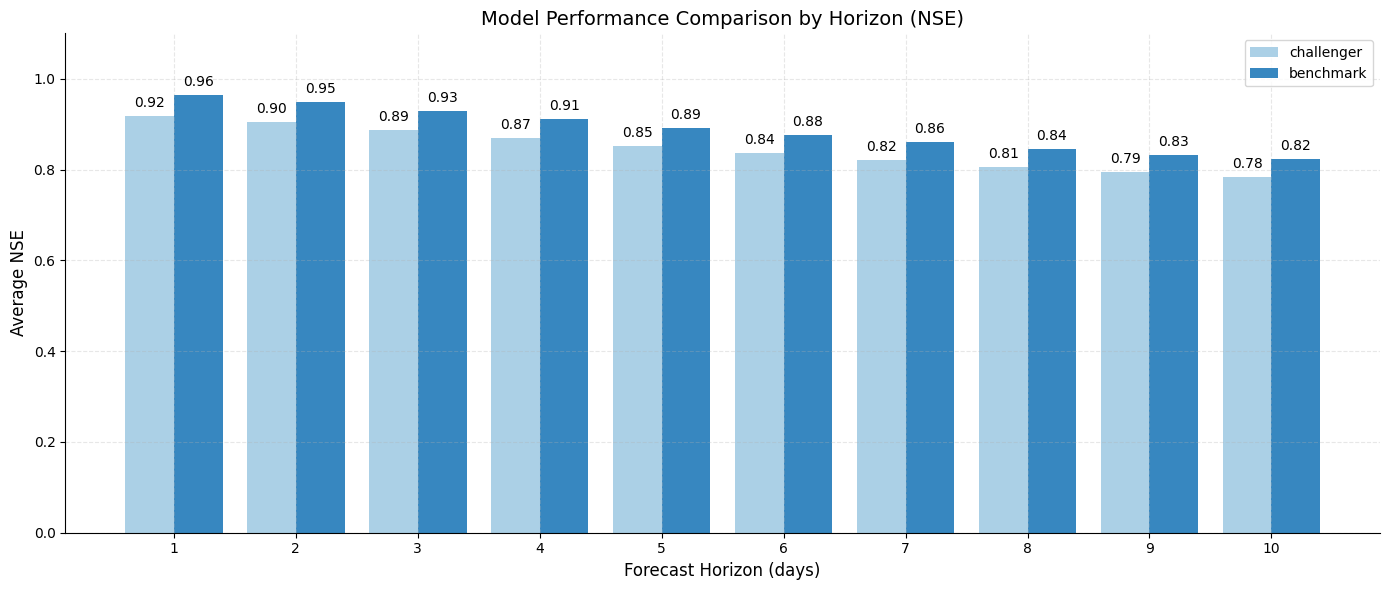

In [16]:
evaluator.plot_nse_comparison(
    "benchmark",
    "challenger",
    metric="NSE",
)